<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/LinearAlgebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習に必要な線形代数

In [20]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 27.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d0b65e5e8ef8cde5348edb0442a60073429b978051ad2cb66cf0e046ba2bb7ed
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## NumPyによるスカラー，ベクトル，行列，テンソルの表現

In [2]:
import numpy as np

# スカラー
alpha = 0.01

# ベクトル（1次元配列）
x = np.array([5.1, 3.5, 1.4, 0.2])
print(f"ベクトル x: shape = {x.shape}")  # (4,)

# 行列（2次元配列）
X = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [4.9, 3.0, 1.4, 0.2],
    [7.0, 3.2, 4.7, 1.4],
])
print(f"行列 X: shape = {X.shape}")  # (3, 4)

# 3階テンソル（例：2枚の 3×4 行列）
T = np.random.randn(2, 3, 4)
print(f"テンソル T: shape = {T.shape}")  # (2, 3, 4)


ベクトル x: shape = (4,)
行列 X: shape = (3, 4)
テンソル T: shape = (2, 3, 4)


## NumPyを用いた内積の計算

In [3]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# 内積の計算方法
dot1 = np.dot(x, y)          # 32
dot2 = x @ y                 # 32（Python 3.5+ の演算子）
dot3 = np.sum(x * y)         # 32（要素積の和）

# コサイン類似度
cos_sim = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
print(f"コサイン類似度: {cos_sim:.4f}")  # 0.9746


コサイン類似度: 0.9746


## ノルム

In [4]:
x = np.array([3, -4, 0, 5])

print(f"L1 ノルム:   {np.linalg.norm(x, ord=1):.2f}")   # 12.00
print(f"L2 ノルム:   {np.linalg.norm(x, ord=2):.4f}")    # 7.0711
print(f"L∞ ノルム:   {np.linalg.norm(x, ord=np.inf)}")   # 5.0


L1 ノルム:   12.00
L2 ノルム:   7.0711
L∞ ノルム:   5.0


## 行列の積

In [5]:
A = np.array([[1, 2], [3, 4], [5, 6]])  # (3, 2)
B = np.array([[7, 8, 9], [10, 11, 12]]) # (2, 3)

C = A @ B                                # (3, 3)
print(f"A @ B:\n{C}")
# [[ 27  30  33]
#  [ 61  68  75]
#  [ 95 106 117]]


A @ B:
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]


## 行列の転置

In [6]:
A = np.array([[1, 2, 3], [4, 5, 6]])  # (2, 3)
print(f"A^T:\n{A.T}")                  # (3, 2)


A^T:
[[1 4]
 [2 5]
 [3 6]]


## アダマール積

In [9]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print(f"アダマール積:\n{A * B}")       # [[ 5, 12], [21, 32]]


アダマール積:
[[ 5 12]
 [21 32]]


## NumPy ブロードキャストの例

In [13]:
X = np.random.randn(4, 3)  # 4サンプル × 3特徴量
W = np.random.randn(3, 2)    # 3入力 → 2出力
b = np.array([0.1, -0.2])  # バイアスの shapeは (2,)

Z = X @ W + b   # (4, 2) + (2,) → ブロードキャスト → (4, 2)
print(f"Z の shape: {Z.shape}")  # (4, 2)
print(f"Z: {Z}")  # (4, 2)


Z の shape: (4, 2)
Z: [[ 0.34000308  3.74116589]
 [ 0.33394783 -1.67804242]
 [-0.94722075  0.84946174]
 [ 1.88748662 -1.20712927]]


## 直交行列

In [14]:
I = np.eye(3)                    # 3×3 単位行列
D = np.diag([2, 3, 5])          # 対角行列
print(f"単位行列:\n{I}")
print(f"対角行列:\n{D}")

# 対称行列の例（共分散行列）
X = np.random.randn(100, 3)
X_centered = X - X.mean(axis=0)
cov = (X_centered.T @ X_centered) / (len(X) - 1)
print(f"共分散行列（対称性の確認）: {np.allclose(cov, cov.T)}")  # True


単位行列:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
対角行列:
[[2 0 0]
 [0 3 0]
 [0 0 5]]
共分散行列（対称性の確認）: True


## 線形回帰の正規方程式

In [15]:
# 線形回帰の正規方程式
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# バイアス項を追加
X_b = np.c_[np.ones(len(X)), X]  # (100, 4)

# 正規方程式で解を計算
w_exact = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f"正規方程式の解: {w_exact}")

# 数値的に安定な方法（lstsq）
w_stable, _, _, _ = np.linalg.lstsq(X_b, y, rcond=None)
print(f"lstsq の解:    {w_stable}")


正規方程式の解: [ 1.24925158 28.3172211  73.99152663 18.79832083]
lstsq の解:    [ 1.24925158 28.3172211  73.99152663 18.79832083]


## 行列のランク

In [16]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"ランク: {np.linalg.matrix_rank(A)}")  # 2（3行目は1,2行目の線形結合）
print(f"行列式: {np.linalg.det(A):.6f}")       # ほぼ 0（ランク落ち）

B = np.array([[1, 0, 2], [0, 1, 3], [1, 1, 5]])
print(f"ランク: {np.linalg.matrix_rank(B)}")  # 2


ランク: 2
行列式: 0.000000
ランク: 2


## 固有値分解

In [17]:
A = np.array([[4, 2], [1, 3]])

eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"固有値: {eigenvalues}")        # [5. 2.]
print(f"固有ベクトル:\n{eigenvectors}") # 列ごとに固有ベクトル

# 検証: Av = λv
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    Av = A @ v
    lam_v = lam * v
    print(f"λ={lam:.1f}: Av = {Av}, λv = {lam_v}, 一致={np.allclose(Av, lam_v)}")

# 対称行列の固有値分解
S = np.array([[3, 1], [1, 2]])
eigenvalues_s, Q = np.linalg.eigh(S)   # eigh は対称行列用（高速・安定）
print(f"\n対称行列の固有値: {eigenvalues_s}")
print(f"Q^T Q ≈ I: {np.allclose(Q.T @ Q, np.eye(2))}")


固有値: [5. 2.]
固有ベクトル:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]
λ=5.0: Av = [4.47213595 2.23606798], λv = [4.47213595 2.23606798], 一致=True
λ=2.0: Av = [-1.41421356  1.41421356], λv = [-1.41421356  1.41421356], 一致=True

対称行列の固有値: [1.38196601 3.61803399]
Q^T Q ≈ I: True


## 特異値分解

In [18]:
# SVD の基本
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])  # (4, 3)

U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
print(f"U: {U.shape}, sigma: {sigma.shape}, Vt: {Vt.shape}")
# U: (4,3), sigma: (3,), Vt: (3,3)
print(f"特異値: {sigma}")

# 復元の確認
A_reconstructed = U @ np.diag(sigma) @ Vt
print(f"復元誤差: {np.linalg.norm(A - A_reconstructed):.2e}")  # ≈ 0

# ランク r=1 での近似
r = 1
A_approx = U[:, :r] @ np.diag(sigma[:r]) @ Vt[:r, :]
print(f"ランク1近似の誤差: {np.linalg.norm(A - A_approx):.4f}")


U: (4, 3), sigma: (3,), Vt: (3, 3)
特異値: [2.54624074e+01 1.29066168e+00 2.40694596e-15]
復元誤差: 1.49e-14
ランク1近似の誤差: 1.2907


## 主成分分析 (PCA)

=== 手動 PCA ===
固有値: [2.93808505 0.9201649  0.14774182 0.02085386]
累積寄与率: [0.72962445 0.95813207 0.99482129 1.        ]

=== scikit-learn PCA ===
説明分散比: [0.72962445 0.22850762]
累積寄与率: [0.72962445 0.95813207]


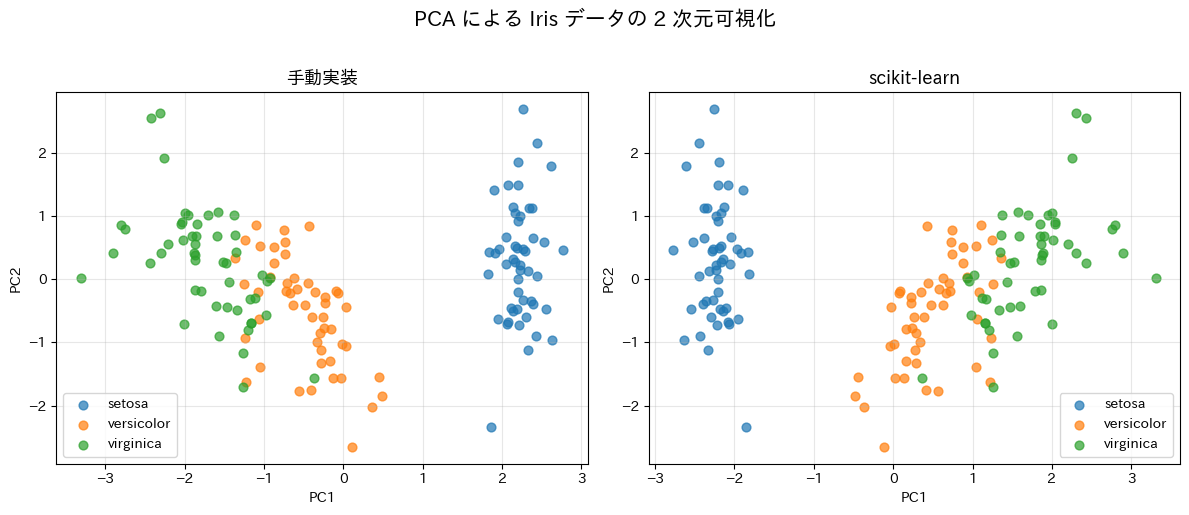

In [21]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import japanize_matplotlib

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)

# ──────────────────────────
# NumPy で手動実装
# ──────────────────────────
cov_matrix = np.cov(X, rowvar=False)  # (4, 4) 共分散行列
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 固有値の大きい順にソート
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 上位 2 成分で射影
Z_manual = X @ eigenvectors[:, :2]

print("=== 手動 PCA ===")
print(f"固有値: {eigenvalues}")
cumulative = np.cumsum(eigenvalues) / eigenvalues.sum()
print(f"累積寄与率: {cumulative}")

# ──────────────────────────
# scikit-learn による PCA
# ──────────────────────────
pca = PCA(n_components=2)
Z_sklearn = pca.fit_transform(X)

print(f"\n=== scikit-learn PCA ===")
print(f"説明分散比: {pca.explained_variance_ratio_}")
print(f"累積寄与率: {pca.explained_variance_ratio_.cumsum()}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, Z, title in [(axes[0], Z_manual, '手動実装'),
                      (axes[1], Z_sklearn, 'scikit-learn')]:
    for cls in range(3):
        mask = iris.target == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], label=iris.target_names[cls],
                   s=40, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA による Iris データの 2 次元可視化', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150)
plt.show()
